Causal Machine Learning for Flood Occurrence Assessment Using a Proxy Infrastructure Indicator

In [ ]:
!pip install econml shap xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 10.7 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.52.0
    Uninstalling shap-0.52.0:
      Successfully uninstalled shap-0.52.0


In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)

df = pd.read_csv("flood_risk_dataset_india.csv")

print(df.head())

    Latitude  Longitude  Rainfall (mm)  Temperature (C)  Humidity (%)  \
0  18.861663  78.835584     218.999493        34.144337     43.912963   
1  35.570715  77.654451      55.353599        28.778774     27.585422   
2  29.227824  73.108463     103.991908        43.934956     30.108738   
3  25.361096  85.610733     198.984191        21.569354     34.453690   
4  12.524541  81.822101     144.626803        32.635692     36.292267   

   River Discharge (m3/s)  Water Level (m)  Elevation (m)    Land Cover  \
0             4236.182888         7.415552     377.465434    Water Body   
1             2472.585219         8.811019    7330.608875        Forest   
2              977.328053         4.631799    2205.873488  Agricultural   
3             3683.208933         2.891787    2512.277800        Desert   
4             2093.390678         3.188466    2001.818223  Agricultural   

  Soil Type  Population Density  Infrastructure  Historical Floods  \
0      Clay         7276.742184         

In [ ]:
# Basic info
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
df.head()

Shape of dataset: (10000, 14)

Column names:
Index(['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (C)',
       'Humidity (%)', 'River Discharge (m3/s)', 'Water Level (m)',
       'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density',
       'Infrastructure', 'Historical Floods', 'Flood Occurred'],
      dtype='object')

First 5 rows:


,Latitude,Longitude,Rainfall (mm),Temperature (C),Humidity (%),River Discharge (m3/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465434,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


In [ ]:
# Define outcome
Y = df["Flood Occurred"]

# Define treatment
T = df["Infrastructure"]

# Define confounders (exclude outcome and treatment)
X = df.drop(columns=["Flood Occurred", "Infrastructure"])

print("Outcome shape:", Y.shape)
print("Treatment shape:", T.shape)
print("Confounders shape:", X.shape)

X.head()

Outcome shape: (10000,)
Treatment shape: (10000,)
Confounders shape: (10000, 12)


,Latitude,Longitude,Rainfall (mm),Temperature (C),Humidity (%),River Discharge (m3/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Historical Floods
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465434,Water Body,Clay,7276.742184,0
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,1
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,0


In [ ]:
# Convert categorical variables to numerical using one-hot encoding
categorical_cols = ["Land Cover", "Soil Type"]
X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True)

print("New feature shape:", X_encoded.shape)
X_encoded.head()

New feature shape: (10000, 18)


,Latitude,Longitude,Rainfall (mm),Temperature (C),Humidity (%),River Discharge (m3/s),Water Level (m),Elevation (m),Population Density,Historical Floods,Land Cover_Desert,Land Cover_Forest,Land Cover_Urban,Land Cover_Water Body,Soil Type_Loam,Soil Type_Peat,Soil Type_Sandy,Soil Type_Silt
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465434,7276.742184,0,False,False,False,True,False,False,False,False
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,6897.736956,1,False,True,False,False,False,True,False,False
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,4361.518494,1,False,False,False,False,True,False,False,False
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,6163.069701,1,True,False,False,False,False,False,True,False
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,6167.964591,0,False,False,False,False,True,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert True/False columns to numeric
X_encoded = X_encoded.astype(float)

# Train-test split
X_train, X_test, Y_train, Y_test, T_train, T_test = train_test_split(
    X_encoded, Y, T, test_size=0.3, random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape)
print("Testing samples:", X_test_scaled.shape)

Training samples: (7000, 18)
Testing samples: (3000, 18)


In [ ]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier

# Define outcome model
model_y = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Define treatment model
model_t = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

In [ ]:
# Ensure binary integer values
Y_train = Y_train.astype(int)
T_train = T_train.astype(int)

# Outcome model
model_y = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Treatment model
model_t = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

# Causal Forest model
cf = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_outcome=True,
    discrete_treatment=True,
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    cv=5,
    random_state=42
)

# Fit model using scaled features
cf.fit(Y_train, T_train, X=X_train_scaled)

# Estimate treatment effects
treatment_effects = cf.effect(X_test_scaled)

print("First 10 treatment effects:")
print(treatment_effects[:10])

print("Average Treatment Effect:", np.mean(treatment_effects))

First 10 treatment effects:
[[ 0.01125782]
 [-0.02601969]
 [-0.00095772]
 [-0.02233372]
 [-0.04099275]
 [-0.05490766]
 [-0.03064867]
 [-0.01433725]
 [-0.0289478 ]
 [ 0.02055747]]
Average Treatment Effect: -0.015876857775508558


In [ ]:
# Train causal forest with scaled features
cf.fit(Y_train, T_train, X=X_train_scaled)

# Estimate treatment effects
treatment_effects = cf.effect(X_test_scaled)

print("First 10 treatment effects:")
print(treatment_effects[:10])

First 10 treatment effects:
[[ 0.01125782]
 [-0.02601969]
 [-0.00095772]
 [-0.02233372]
 [-0.04099275]
 [-0.05490766]
 [-0.03064867]
 [-0.01433725]
 [-0.0289478 ]
 [ 0.02055747]]


In [ ]:
 # Calculate Average Treatment Effect (ATE)

ate = np.mean(treatment_effects)

print("Average Treatment Effect (ATE):", ate)

Average Treatment Effect (ATE): -0.015876857775508558


In [ ]:
# Create dataframe with treatment effects
results = X_test.copy()
results["Treatment Effect"] = treatment_effects

# show first rows
results.head()

,Latitude,Longitude,Rainfall (mm),Temperature (C),Humidity (%),River Discharge (m3/s),Water Level (m),Elevation (m),Population Density,Historical Floods,Land Cover_Desert,Land Cover_Forest,Land Cover_Urban,Land Cover_Water Body,Soil Type_Loam,Soil Type_Peat,Soil Type_Sandy,Soil Type_Silt,Treatment Effect
6252,17.786834,70.809873,290.684548,32.380421,69.941956,2149.788641,3.760597,5732.622500,6560.217327,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.011258
4684,30.489654,90.892009,58.531742,38.362878,58.367639,4072.418785,7.698761,7382.350078,4459.140280,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.026020
1731,26.092979,74.056274,296.806505,32.078594,21.928201,923.416760,0.560510,7186.187445,8658.024273,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-0.000958
4742,9.032117,91.371264,38.474462,24.974476,76.301193,3350.129157,5.704189,8430.156974,7620.791748,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.022334
4521,24.736395,95.315406,106.425281,40.369730,68.557714,4741.233104,6.884878,3253.443151,6311.284520,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.040993


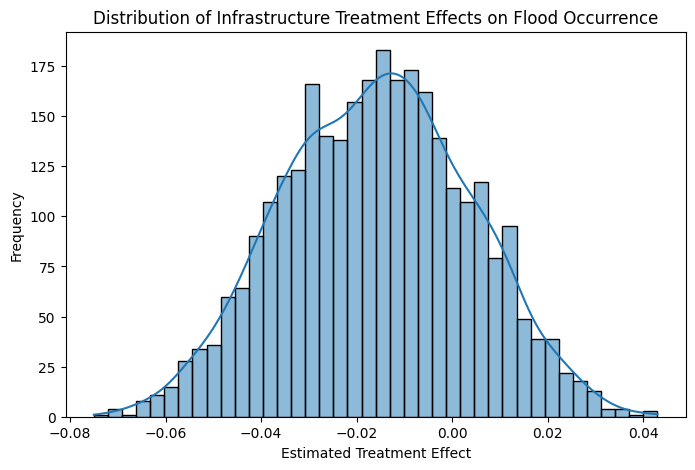

In [ ]:
# Plot distribution of causal effects

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(results["Treatment Effect"], bins=40, kde=True)

plt.title("Distribution of Infrastructure Treatment Effects on Flood Occurrence")
plt.xlabel("Estimated Treatment Effect")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# compare treatment effect by rainfall levels

results["Rainfall Category"] = pd.qcut(results["Rainfall (mm)"], q=4, labels=[
    "Low Rainfall",
    "Moderate Rainfall",
    "High Rainfall",
    "Extreme Rainfall"
])

rainfall_effect = results.groupby("Rainfall Category")["Treatment Effect"].mean()

print(rainfall_effect)

Rainfall Category
Low Rainfall        -0.011699
Moderate Rainfall   -0.016573
High Rainfall       -0.017626
Extreme Rainfall    -0.017609
Name: Treatment Effect, dtype: float64


/tmp/ipykernel_48321/1954983740.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rainfall_effect = results.groupby("Rainfall Category")["Treatment Effect"].mean()


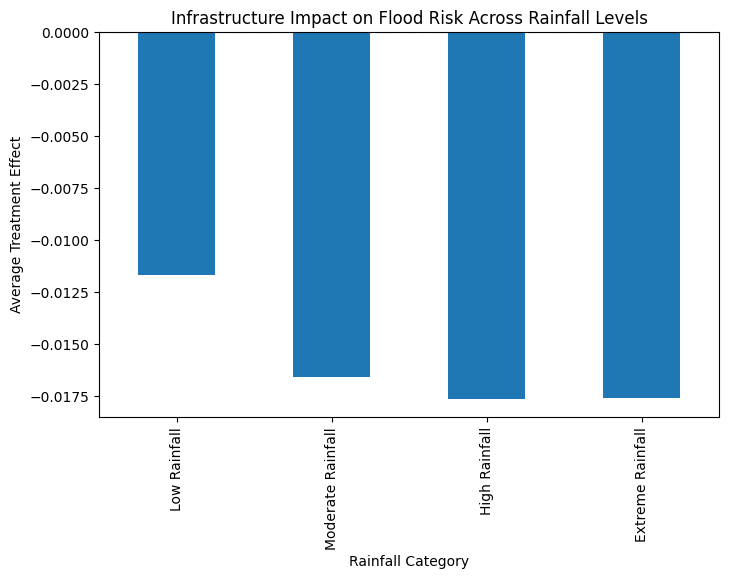

In [ ]:
# Visualize treatment effect by rainfall category

rainfall_effect.plot(kind='bar', figsize=(8,5))

plt.title("Infrastructure Impact on Flood Risk Across Rainfall Levels")
plt.xlabel("Rainfall Category")
plt.ylabel("Average Treatment Effect")

plt.axhline(0, linestyle='--')

plt.show()

In [ ]:
# Feature importance from the causal forest

# Extract feature importance from Causal Forest
feature_importance = np.array(cf.feature_importances_)

# Build importance table
causal_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

# Sort by importance
causal_importance = (
    causal_importance
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

# Display top causal drivers
print("Top 10 Causal Drivers:")
print(causal_importance.head(10))

Top 10 Causal Drivers:
                  Feature  Importance
0         Water Level (m)    0.149560
1               Longitude    0.131838
2         Temperature (C)    0.109300
3  River Discharge (m3/s)    0.103429
4            Humidity (%)    0.099727
5           Rainfall (mm)    0.098703
6                Latitude    0.096169
7      Population Density    0.085006
8           Elevation (m)    0.083099
9       Land Cover_Desert    0.007095


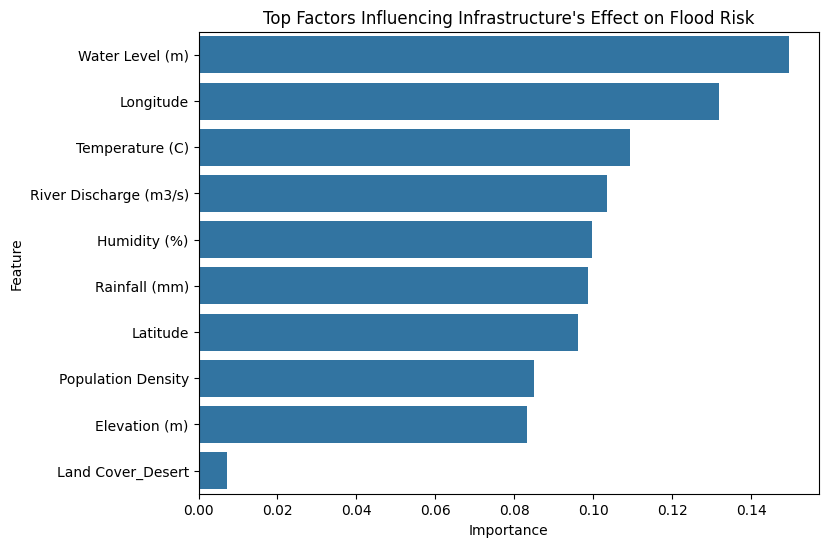

In [ ]:
# Plot feature importance from the Causal Forest

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=causal_importance.head(10)
)

plt.title("Top Factors Influencing Infrastructure's Effect on Flood Risk")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# Confidence intervals for treatment effects

lower, upper = cf.effect_interval(X_test)

print("Lower bounds (first 10):")
print(lower[:10])

print("\nUpper bounds (first 10):")
print(upper[:10])

Lower bounds (first 10):
[-0.1176072  -0.12935843 -0.11716435 -0.1148394  -0.10852109 -0.11632928
 -0.12765636 -0.10970416 -0.12160925 -0.10378619]

Upper bounds (first 10):
[0.05996271 0.07544774 0.06596985 0.06576658 0.05549128 0.05579414
 0.06642709 0.04744279 0.07480821 0.05493828]


In [ ]:
# Average Treatment Effect with confidence interval

ate = treatment_effects.mean()
ate_lower = lower.mean()
ate_upper = upper.mean()

print("Average Treatment Effect (ATE):", ate)
print("95% Confidence Interval:", (ate_lower, ate_upper))

Average Treatment Effect (ATE): -0.015876857775508558
95% Confidence Interval: (np.float64(-0.11020945741447852), np.float64(0.05737371636673443))


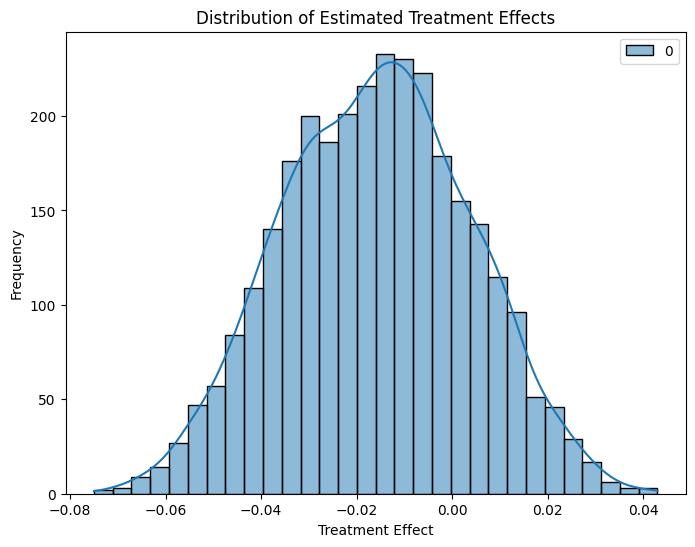

In [ ]:
#  Plot distribution of treatment effects

plt.figure(figsize=(8,6))

sns.histplot(treatment_effects, bins=30, kde=True)

plt.title("Distribution of Estimated Treatment Effects")
plt.xlabel("Treatment Effect")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Placebo / Refutation Test

# Randomly shuffle treatment
T_random = np.random.permutation(T_train)

# Train placebo causal forest using SAME settings as main model
cf_placebo = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_outcome=True,
    discrete_treatment=True,
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    cv=5,
    random_state=42
)

cf_placebo.fit(Y_train, T_random, X=X_train_scaled)

placebo_effects = cf_placebo.effect(X_test_scaled)


print("Placebo Average Treatment Effect:", np.mean(placebo_effects))

Placebo Average Treatment Effect: 0.021467250537649345


In [ ]:
# ==========================================================
#  Repeated Placebo Permutation Test
# ==========================================================

import numpy as np
import pandas as pd

# Number of placebo repetitions (fast version)
n_permutations = 10

placebo_ates = []

for i in range(n_permutations):

    # Randomly shuffle treatment labels
    T_random = np.random.permutation(T_train)

    # Train placebo model
    cf_placebo = CausalForestDML(
        model_y=model_y,
        model_t=model_t,
        discrete_outcome=True,
        discrete_treatment=True,
        n_estimators=200,      # Reduced for faster execution
        min_samples_leaf=20,
        max_depth=10,
        cv=5,
        random_state=i
    )

    cf_placebo.fit(Y_train, T_random, X=X_train_scaled)

    placebo_effect = cf_placebo.effect(X_test_scaled)

    placebo_ates.append(np.mean(placebo_effect))

# Convert to NumPy array
placebo_ates = np.array(placebo_ates)

# Summary statistics
mean_placebo = placebo_ates.mean()
std_placebo = placebo_ates.std(ddof=1)

# Empirical 95% confidence interval
lower95 = np.percentile(placebo_ates, 2.5)
upper95 = np.percentile(placebo_ates, 97.5)

# Main ATE
main_ate = np.mean(treatment_effects)

# Empirical two-sided p-value
empirical_p = np.mean(np.abs(placebo_ates) >= np.abs(main_ate))

print("\n--------------------------------")
print("Repeated Placebo Test")
print("--------------------------------")
print(f"Number of permutations : {n_permutations}")
print(f"Mean Placebo ATE       : {mean_placebo:.6f}")
print(f"Standard Deviation     : {std_placebo:.6f}")
print(f"95% CI                : ({lower95:.6f}, {upper95:.6f})")
print(f"Empirical p-value     : {empirical_p:.6f}")

# Save results
placebo_summary = pd.DataFrame({
    "Permutations": [n_permutations],
    "Mean_Placebo_ATE": [mean_placebo],
    "Std": [std_placebo],
    "Lower95": [lower95],
    "Upper95": [upper95],
    "Empirical_p": [empirical_p]
})

placebo_summary.to_csv(
    "Repeated_Placebo_Test.csv",
    index=False
)

print("\nRepeated placebo summary saved as Repeated_Placebo_Test.csv")


--------------------------------
Repeated Placebo Test
--------------------------------
Number of permutations : 10
Mean Placebo ATE       : 0.000965
Standard Deviation     : 0.013991
95% CI                : (-0.017676, 0.024931)
Empirical p-value     : 0.200000

Repeated placebo summary saved as Repeated_Placebo_Test.csv


In [ ]:

# Sensitivity analysis (remove rainfall variable)

# Remove rainfall variable
X_train_sens = X_train.drop(columns=["Rainfall (mm)"], errors="ignore")
X_test_sens = X_test.drop(columns=["Rainfall (mm)"], errors="ignore")

# Scale features again after removing column
scaler_sens = StandardScaler()

X_train_sens_scaled = scaler_sens.fit_transform(X_train_sens)
X_test_sens_scaled = scaler_sens.transform(X_test_sens)

# Train causal forest with same parameters
cf_sens = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_outcome=True,
    discrete_treatment=True,
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    cv=5,
    random_state=42
)

cf_sens.fit(Y_train, T_train, X=X_train_sens_scaled)

# Estimate treatment effects
sens_effects = cf_sens.effect(X_test_sens_scaled)

print("ATE without rainfall variable:", sens_effects.mean())

ATE without rainfall variable: -0.01717527791746412


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
100%|===================| 2992/3000 [02:50<00:00]       /tmp/ipykernel_4073/4197886829.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test.columns)


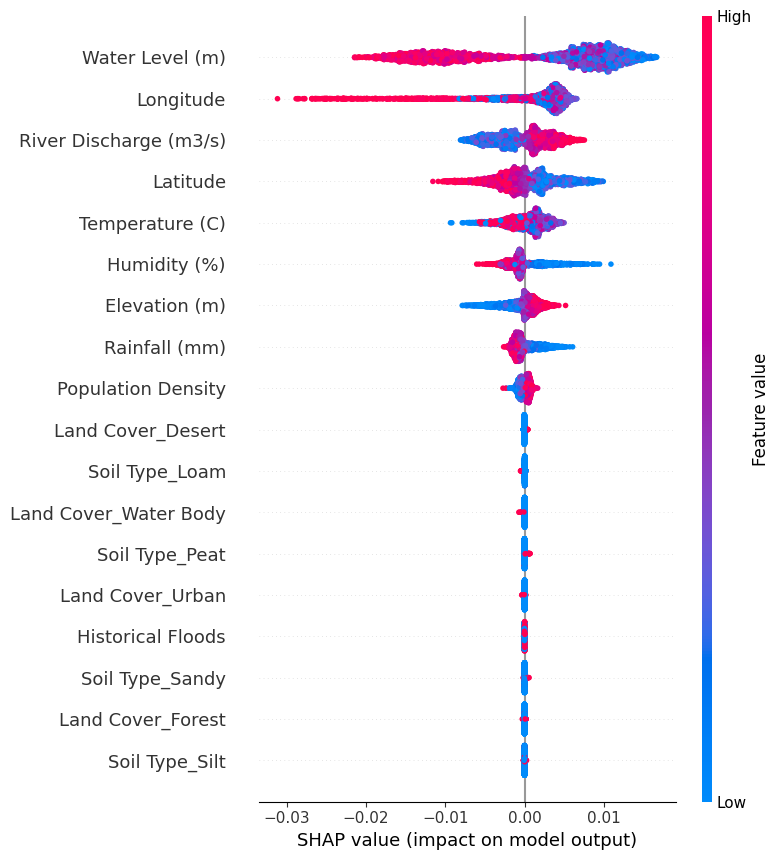

In [ ]:
#  SHAP interpretation for treatment effects
import shap
# Train surrogate model to approximate treatment effects
surrogate = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

surrogate.fit(X_test_scaled, treatment_effects)

# Create SHAP explainer
explainer = shap.Explainer(surrogate, X_test_scaled)

# Compute SHAP values
shap_values = explainer(X_test_scaled)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test.columns)

In [ ]:
# ============================================================
# Mean Absolute SHAP Values with 95% Confidence Intervals
# ============================================================

import numpy as np
import pandas as pd

# Absolute SHAP values
abs_shap = np.abs(shap_values.values)

# Mean absolute SHAP values
mean_shap = abs_shap.mean(axis=0)

# Standard deviation
std_shap = abs_shap.std(axis=0)

# Standard error
se_shap = std_shap / np.sqrt(abs_shap.shape[0])

# 95% confidence intervals
lower95 = mean_shap - 1.96 * se_shap
upper95 = mean_shap + 1.96 * se_shap

# Summary table
shap_summary = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": mean_shap,
    "Std": std_shap,
    "Lower95": lower95,
    "Upper95": upper95
})

# Sort by importance
shap_summary = shap_summary.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

print(shap_summary)

# Save results
shap_summary.to_csv(
    "SHAP_Mean_Absolute_Values.csv",
    index=False
)

                   Feature  Mean_Absolute_SHAP       Std   Lower95   Upper95
6          Water Level (m)            0.009767  0.003744  0.009633  0.009901
1                Longitude            0.004799  0.004661  0.004632  0.004966
5   River Discharge (m3/s)            0.002826  0.001764  0.002762  0.002889
0                 Latitude            0.002782  0.002264  0.002701  0.002863
3          Temperature (C)            0.001861  0.001267  0.001816  0.001906
4             Humidity (%)            0.001677  0.001440  0.001625  0.001728
7            Elevation (m)            0.001469  0.001374  0.001419  0.001518
2            Rainfall (mm)            0.001152  0.000875  0.001121  0.001183
8       Population Density            0.000505  0.000297  0.000495  0.000516
10       Land Cover_Desert            0.000052  0.000044  0.000051  0.000054
14          Soil Type_Loam            0.000042  0.000044  0.000040  0.000043
13   Land Cover_Water Body            0.000037  0.000047  0.000035  0.000038

/tmp/ipykernel_63185/1279170945.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Rainfall_Bin")


                     Rainfall_Bin  Mean_Rainfall  Mean_CATE  Count
0  (0.013399999999999999, 30.234]      15.379699  -0.009063    300
1                (30.234, 62.004]      46.348872  -0.012115    300
2                (62.004, 92.848]      77.494173  -0.015863    300
3               (92.848, 122.796]     108.271579  -0.017278    300
4              (122.796, 152.343]     137.023442  -0.016363    300
5              (152.343, 181.021]     166.715701  -0.017275    300
6              (181.021, 208.482]     193.898340  -0.018555    300
7              (208.482, 239.594]     223.953707  -0.017124    300
8              (239.594, 267.957]     253.661477  -0.017945    300
9              (267.957, 299.909]     284.005417  -0.017188    300


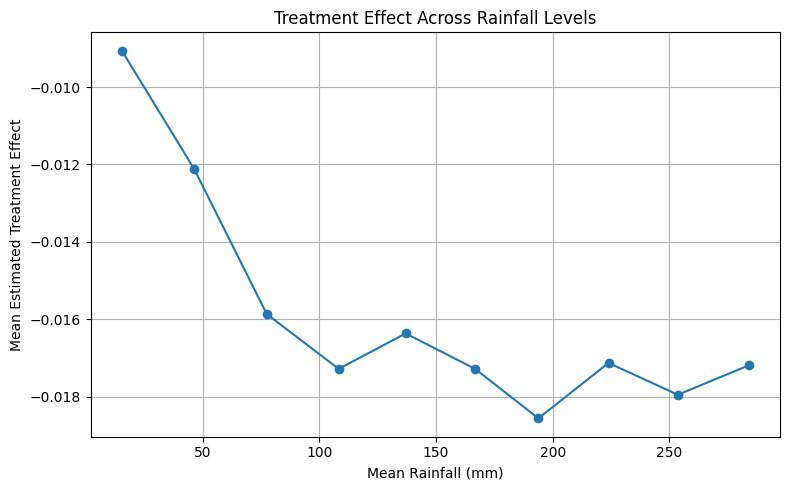

In [ ]:
# ==========================================================
#  Rainfall Threshold Analysis
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe
threshold_df = pd.DataFrame({
    "Rainfall": X_test["Rainfall (mm)"].values,
    "TreatmentEffect": treatment_effects.flatten() # Flatten treatment_effects
})

# Divide rainfall into 10 equal-frequency bins
threshold_df["Rainfall_Bin"] = pd.qcut(
    threshold_df["Rainfall"],
    q=10,
    duplicates="drop"
)

# Mean treatment effect within each rainfall bin
threshold_summary = (
    threshold_df
    .groupby("Rainfall_Bin")
    .agg(
        Mean_Rainfall=("Rainfall","mean"),
        Mean_CATE=("TreatmentEffect","mean"),
        Count=("TreatmentEffect","size")
    )
    .reset_index()
)

print(threshold_summary)

threshold_summary.to_csv(
    "Rainfall_Threshold_Analysis.csv",
    index=False
)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    threshold_summary["Mean_Rainfall"],
    threshold_summary["Mean_CATE"],
    marker="o"
)

plt.xlabel("Mean Rainfall (mm)")
plt.ylabel("Mean Estimated Treatment Effect")
plt.title("Treatment Effect Across Rainfall Levels")

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
#  Create policy zones based on treatment effects

results["Policy Zone"] = pd.cut(
    results["Treatment Effect"],
    bins=[-100, -0.02, -0.01, 0.01, 100],
    labels=[
        "High Infrastructure Benefit",
        "Moderate Infrastructure Benefit",
        "Neutral Impact",
        "Potential Risk Increase"
    ]
)

# Count observations in each zone
policy_counts = results["Policy Zone"].value_counts()

print(policy_counts)

Policy Zone
High Infrastructure Benefit        1250
Neutral Impact                      873
Moderate Infrastructure Benefit     580
Potential Risk Increase             297
Name: count, dtype: int64


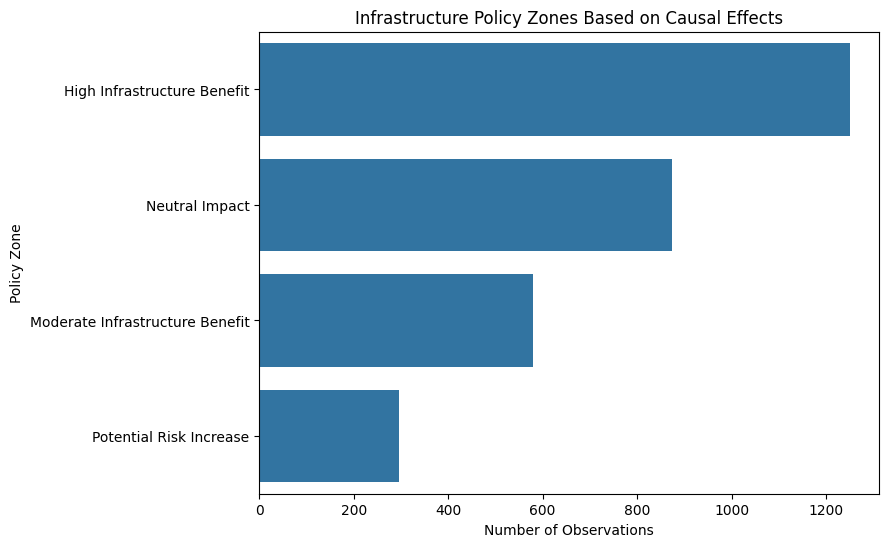

In [ ]:
# Plot policy zone distribution

plt.figure(figsize=(8,6))

sns.countplot(
    data=results,
    y="Policy Zone",
    order=results["Policy Zone"].value_counts().index
)

plt.title("Infrastructure Policy Zones Based on Causal Effects")
plt.xlabel("Number of Observations")
plt.ylabel("Policy Zone")

plt.show()

In [ ]:
#  Counterfactual infrastructure scenario

# Counterfactual: assume all regions receive infrastructure
T0 = np.zeros_like(T_test)   # no infrastructure
T1 = np.ones_like(T_test)    # infrastructure added

# Estimate counterfactual effect
counterfactual_effect = cf.effect(X_test_scaled, T0=T0, T1=T1)

print("Average Counterfactual Effect (Infrastructure vs No Infrastructure):")
print(counterfactual_effect.mean())

Average Counterfactual Effect (Infrastructure vs No Infrastructure):
-0.015876857775508558


In [ ]:
#  Cluster treatment effects

from sklearn.cluster import KMeans

# Reshape treatment effects for clustering
te_values = treatment_effects.reshape(-1, 1)

# Apply clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(te_values)

# Add cluster labels
results["Effect Cluster"] = clusters

# Count observations in each cluster
cluster_counts = results["Effect Cluster"].value_counts()

print(cluster_counts)

Effect Cluster
0    1286
2     910
1     804
Name: count, dtype: int64


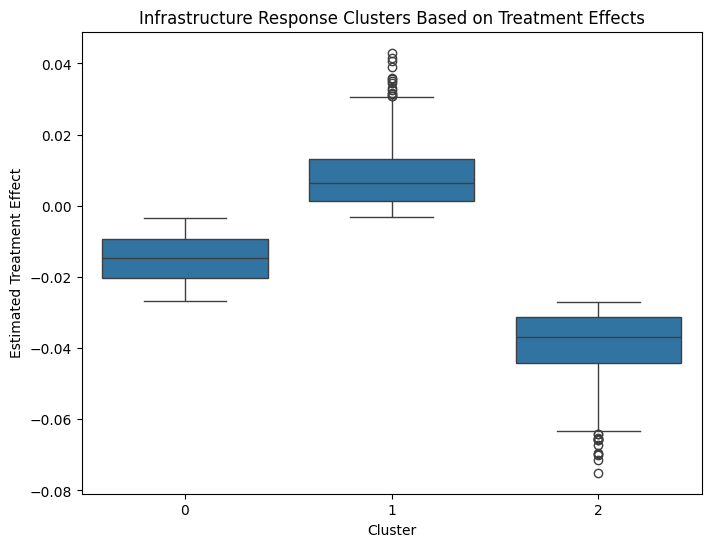

In [ ]:
#  Visualize treatment effect clusters


plt.figure(figsize=(8,6))

sns.boxplot(
    x="Effect Cluster",
    y="Treatment Effect",
    data=results
)

plt.title("Infrastructure Response Clusters Based on Treatment Effects")
plt.xlabel("Cluster")
plt.ylabel("Estimated Treatment Effect")

plt.show()

In [ ]:
#  Double Machine Learning validation

from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor

# Define models
model_y = RandomForestRegressor(n_estimators=100, random_state=42)
model_t = RandomForestRegressor(n_estimators=100, random_state=42)

# DML estimator
dml = LinearDML(model_y=model_y, model_t=model_t, random_state=42)

# Train model using scaled features
dml.fit(Y_train, T_train, X=X_train_scaled)

# Estimate treatment effects
dml_effects = dml.effect(X_test_scaled)

print("DML Average Treatment Effect:", dml_effects.mean())

DML Average Treatment Effect: -0.0166608355017216


In [ ]:
# Rank areas by infrastructure benefit (uplift ranking)

# Add treatment effects to dataset
results["Uplift Score"] = treatment_effects

# Rank observations by uplift score
uplift_ranking = results.sort_values(by="Uplift Score")

# Show top 10 most beneficial areas
print("Top 10 areas benefiting most from infrastructure:")
print(uplift_ranking.head(10))

# Show 10 areas with lowest benefit
print("\nAreas with lowest or negative benefit:")
print(uplift_ranking.tail(10))

Top 10 areas benefiting most from infrastructure:
       Latitude  Longitude  Rainfall (mm)  Temperature (C)  Humidity (%)  \
5916  36.552701  75.621868     177.932207        18.464685     50.398700   
6258  32.252448  68.587232     168.458722        33.276735     51.563800   
2147  18.376150  68.432398     180.447886        15.620660     96.436991   
7927  33.041252  69.418443     113.556913        15.179245     69.218900   
1957  20.216194  95.666458     204.488249        40.881939     75.775641   
3542  12.260736  69.527527     108.820145        17.116410     84.248150   
9123  33.956935  96.411899     283.569698        28.864753     67.940879   
2319  19.919611  96.131663      61.466169        22.677121     50.978821   
8897  24.778975  84.756824     193.898834        38.701568     51.589301   
3334  33.821876  80.083432     290.780773        43.310406     56.635171   

      River Discharge (m3/s)  Water Level (m)  Elevation (m)  \
5916              731.792253         6.870766    

In [ ]:
# Identify priority infrastructure investment zones

# Select top 20% areas with strongest flood-risk reduction
threshold = results["Uplift Score"].quantile(0.20)

priority_zones = results[results["Uplift Score"] <= threshold]

print("Number of priority investment zones:")
print(len(priority_zones))

print("\nSample of priority zones:")
print(priority_zones.head())

Number of priority investment zones:
600

Sample of priority zones:
       Latitude  Longitude  Rainfall (mm)  Temperature (C)  Humidity (%)  \
4521  24.736395  95.315406     106.425281        40.369730     68.557714   
6340  15.176426  68.041346     122.617779        25.928058     58.192405   
2249  11.333057  96.132222       8.589511        24.473889     75.190619   
4947  29.507191  80.793164     278.061661        28.017675     64.126030   
4949  32.506150  76.718326     273.742496        33.551836     67.245703   

      River Discharge (m3/s)  Water Level (m)  Elevation (m)  \
4521             4741.233104         6.884878    3253.443151   
6340             3682.827171         9.471104    1260.110425   
2249             3034.982387         7.555770    5861.309951   
4947             2122.308602         9.354507     208.371258   
4949              674.846680         7.878107    4436.556704   

      Population Density  Historical Floods  ...  Land Cover_Water Body  \
4521         63

In [ ]:
# ============================================================
#  Validation under Different Hydro-Climatic Conditions
# ============================================================

print("="*70)
print("Hydro-Climatic Validation")
print("="*70)

# Copy test dataset
validation_df = X_test.copy()

# Estimated treatment effects
validation_df["Treatment Effect"] = treatment_effects.flatten()

# -------------------------------------------------
# Rainfall-based validation
# -------------------------------------------------

validation_df["Rainfall Group"] = pd.qcut(
    validation_df["Rainfall (mm)"],
    q=4,
    labels=[
        "Low Rainfall",
        "Moderate Rainfall",
        "High Rainfall",
        "Extreme Rainfall"
    ]
)

rainfall_validation = (
    validation_df
    .groupby("Rainfall Group", observed=False)
    .agg(
        Samples=("Treatment Effect","count"),
        Mean_ATE=("Treatment Effect","mean"),
        Std=("Treatment Effect","std")
    )
)

rainfall_validation["Lower95"] = (
    rainfall_validation["Mean_ATE"]
    - 1.96*rainfall_validation["Std"]/np.sqrt(rainfall_validation["Samples"])
)

rainfall_validation["Upper95"] = (
    rainfall_validation["Mean_ATE"]
    + 1.96*rainfall_validation["Std"]/np.sqrt(rainfall_validation["Samples"])
)

print("\nRainfall Validation")
print(rainfall_validation)

# -------------------------------------------------
# River discharge validation
# -------------------------------------------------

validation_df["Discharge Group"] = pd.qcut(
    validation_df["River Discharge (m3/s)"],
    q=2,
    labels=[
        "Low Discharge",
        "High Discharge"
    ]
)

discharge_validation = (
    validation_df
    .groupby("Discharge Group", observed=False)
    .agg(
        Samples=("Treatment Effect","count"),
        Mean_ATE=("Treatment Effect","mean"),
        Std=("Treatment Effect","std")
    )
)

discharge_validation["Lower95"] = (
    discharge_validation["Mean_ATE"]
    - 1.96*discharge_validation["Std"]/np.sqrt(discharge_validation["Samples"])
)

discharge_validation["Upper95"] = (
    discharge_validation["Mean_ATE"]
    + 1.96*discharge_validation["Std"]/np.sqrt(discharge_validation["Samples"])
)

print("\nDischarge Validation")
print(discharge_validation)

# -------------------------------------------------
# Export
# -------------------------------------------------

import os
os.makedirs("results_outputs", exist_ok=True)

rainfall_validation.to_csv(
    "results_outputs/rainfall_validation.csv"
)

discharge_validation.to_csv(
    "results_outputs/discharge_validation.csv"
)

print("\nValidation tables exported successfully.")

Hydro-Climatic Validation

Rainfall Validation
                   Samples  Mean_ATE       Std   Lower95   Upper95
Rainfall Group                                                    
Low Rainfall           750 -0.011699  0.019888 -0.013123 -0.010276
Moderate Rainfall      750 -0.016573  0.020382 -0.018032 -0.015114
High Rainfall          750 -0.017626  0.018472 -0.018948 -0.016304
Extreme Rainfall       750 -0.017609  0.018792 -0.018954 -0.016264

Discharge Validation
                 Samples  Mean_ATE       Std   Lower95   Upper95
Discharge Group                                                 
Low Discharge       1500 -0.018926  0.018322 -0.019853 -0.017998
High Discharge      1500 -0.012828  0.020246 -0.013853 -0.011804

Validation tables exported successfully.


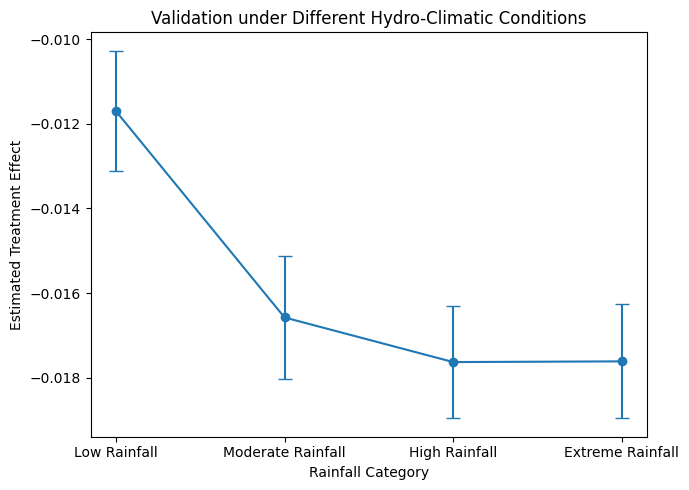

In [ ]:
import os

plt.figure(figsize=(7,5))

plt.errorbar(
    rainfall_validation.index.astype(str),
    rainfall_validation["Mean_ATE"],
    yerr=[
        rainfall_validation["Mean_ATE"]-rainfall_validation["Lower95"],
        rainfall_validation["Upper95"]-rainfall_validation["Mean_ATE"]
    ],
    fmt='o-',
    capsize=5
)

plt.ylabel("Estimated Treatment Effect")
plt.xlabel("Rainfall Category")
plt.title("Validation under Different Hydro-Climatic Conditions")

plt.tight_layout()
os.makedirs("results_outputs/figures", exist_ok=True)
plt.savefig(
    "results_outputs/figures/hydroclimatic_validation.png",
    dpi=300
)

plt.show()

In [ ]:
# ============================================
# Treatment Group Summary
# ============================================

import pandas as pd

# Treatment variable (0 = Untreated, 1 = Treated)
treatment = df["Infrastructure"]   # <-- replace if your variable name differs

summary = (
    treatment.value_counts()
    .sort_index()
    .rename_axis("Treatment")
    .reset_index(name="Count")
)

summary["Group"] = summary["Treatment"].map({
    0: "Untreated (0)",
    1: "Treated (1)"
})

summary["Percentage (%)"] = (
    summary["Count"] / summary["Count"].sum() * 100
).round(2)

summary = summary[["Group", "Count", "Percentage (%)"]]

print(summary)

# Save table
summary.to_csv("Treatment_Group_Summary.csv", index=False)

print("\nTreatment summary saved as Treatment_Group_Summary.csv")

           Group  Count  Percentage (%)
0  Untreated (0)   4980            49.8
1    Treated (1)   5020            50.2

Treatment summary saved as Treatment_Group_Summary.csv


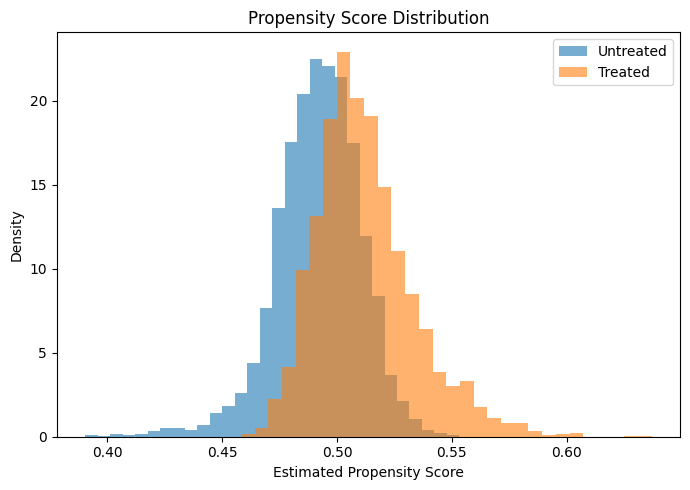

In [ ]:
# ============================================================
# Propensity Score Overlap Diagnostics
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# --------------------------------------------
# Covariates (exclude treatment and outcome)
# --------------------------------------------
# Use the already encoded features from X_encoded
X_overlap = X_encoded.copy()

# Treatment
T = df["Infrastructure"]

# --------------------------------------------
# Estimate propensity scores
# --------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

# Fit using the encoded features
rf.fit(X_overlap, T)

propensity_scores = rf.predict_proba(X_overlap)[:, 1]

# --------------------------------------------
# Plot overlap
# --------------------------------------------
plt.figure(figsize=(7,5))

plt.hist(
    propensity_scores[T==0],
    bins=30,
    density=True,
    alpha=0.6,
    label="Untreated"
)

plt.hist(
    propensity_scores[T==1],
    bins=30,
    density=True,
    alpha=0.6,
    label="Treated"
)

plt.xlabel("Estimated Propensity Score")
plt.ylabel("Density")
plt.title("Propensity Score Distribution")
plt.legend()

plt.tight_layout()
plt.savefig("Propensity_Score_Overlap.png", dpi=300)
plt.show()

In [ ]:
print("--------------------------------")
print("Common Support")
print("--------------------------------")

treated = propensity_scores[T==1]
control = propensity_scores[T==0]

lower = max(treated.min(), control.min())
upper = min(treated.max(), control.max())

print(f"Overlap interval: [{lower:.3f}, {upper:.3f}]")

--------------------------------
Common Support
--------------------------------
Overlap interval: [0.458, 0.553]


In [ ]:
import numpy as np

print("--------------------------------")
print("Standardized Mean Differences")
print("--------------------------------")

covariates = X_encoded.columns # Use X_encoded columns

rows = []

for col in covariates:

    # Use X_encoded instead of X for calculations
    treated_values = X_encoded.loc[T==1, col]
    control_values = X_encoded.loc[T==0, col]

    mean_t = treated_values.mean()
    mean_c = control_values.mean()

    var_t = treated_values.var()
    var_c = control_values.var()

    pooled_sd = np.sqrt((var_t + var_c)/2)

    smd = (mean_t - mean_c)/pooled_sd

    rows.append([col, smd])

smd_table = pd.DataFrame(rows, columns=["Variable","SMD"])

print(smd_table)

smd_table.to_csv(
    "Standardized_Mean_Differences.csv",
    index=False
)

--------------------------------
Standardized Mean Differences
--------------------------------
                  Variable       SMD
0                 Latitude -0.022524
1                Longitude  0.064550
2            Rainfall (mm) -0.001602
3          Temperature (C) -0.037949
4             Humidity (%) -0.024529
5   River Discharge (m3/s)  0.012969
6          Water Level (m) -0.013192
7            Elevation (m)  0.004511
8       Population Density  0.005573
9        Historical Floods -0.006779
10       Land Cover_Desert -0.010501
11       Land Cover_Forest -0.005504
12        Land Cover_Urban  0.000125
13   Land Cover_Water Body  0.030649
14          Soil Type_Loam  0.011114
15          Soil Type_Peat -0.034770
16         Soil Type_Sandy -0.028153
17          Soil Type_Silt  0.032649


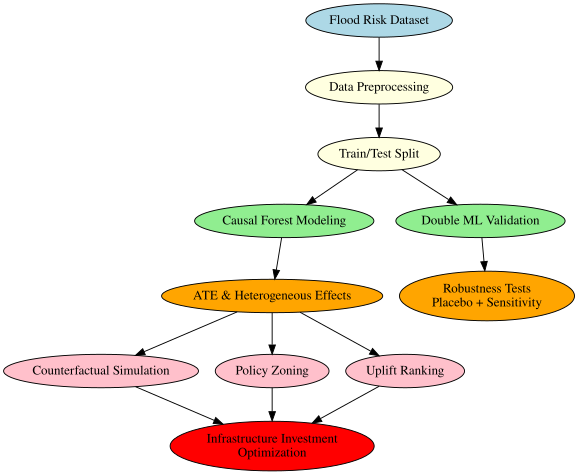

In [ ]:
#  Colored tree framework diagram

!pip install graphviz

from graphviz import Digraph
from IPython.display import display

g = Digraph('Flood Framework', format='png')

g.attr(rankdir='TB', size='8,8')

# Root
g.node('A', 'Flood Risk Dataset', style='filled', fillcolor='lightblue')

# Level 1
g.node('B', 'Data Preprocessing', style='filled', fillcolor='lightyellow')
g.node('C', 'Train/Test Split', style='filled', fillcolor='lightyellow')

# Level 2
g.node('D', 'Causal Forest Modeling', style='filled', fillcolor='lightgreen')
g.node('E', 'Double ML Validation', style='filled', fillcolor='lightgreen')

# Level 3
g.node('F', 'ATE & Heterogeneous Effects', style='filled', fillcolor='orange')
g.node('G', 'Robustness Tests\nPlacebo + Sensitivity', style='filled', fillcolor='orange')

# Level 4
g.node('H', 'Counterfactual Simulation', style='filled', fillcolor='pink')
g.node('I', 'Policy Zoning', style='filled', fillcolor='pink')
g.node('J', 'Uplift Ranking', style='filled', fillcolor='pink')

# Final
g.node('K', 'Infrastructure Investment\nOptimization', style='filled', fillcolor='red')

# Connections
g.edges([('A','B'),('B','C'),('C','D'),('C','E')])
g.edges([('D','F'),('E','G')])
g.edges([('F','H'),('F','I'),('F','J')])
g.edge('H','K')
g.edge('I','K')
g.edge('J','K')

display(g)

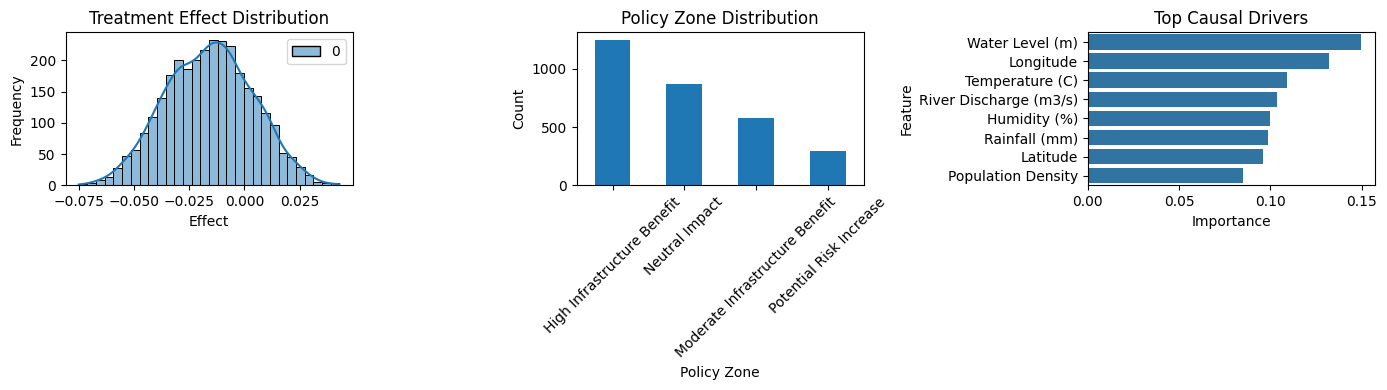

In [ ]:
#  Create results dashboard

plt.figure(figsize=(14,4))

# --- Panel 1: Treatment Effect Distribution ---
plt.subplot(1,3,1)
sns.histplot(treatment_effects, bins=30, kde=True)
plt.title("Treatment Effect Distribution")
plt.xlabel("Effect")
plt.ylabel("Frequency")

# --- Panel 2: Policy Zone Counts ---
plt.subplot(1,3,2)
results["Policy Zone"].value_counts().plot(kind="bar")
plt.title("Policy Zone Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)

# --- Panel 3: Top Causal Feature Importance ---
plt.subplot(1,3,3)
top_features = causal_importance.head(8)
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top Causal Drivers")

plt.tight_layout()
plt.show()

In [ ]:
#  Create summary results table

summary_table = pd.DataFrame({
    "Analysis": [
        "Average Treatment Effect",
        "Placebo Test Effect",
        "Sensitivity Analysis (No Rainfall)",
        "Counterfactual Effect (Infrastructure vs No Infrastructure)"
    ],
    "Estimated Value": [
        ate,
        placebo_effects.mean(),
        sens_effects.mean(),
        counterfactual_effect.mean()
    ]
})

print(summary_table)


                                            Analysis  Estimated Value
0                           Average Treatment Effect        -0.015877
1                                Placebo Test Effect         0.021467
2                 Sensitivity Analysis (No Rainfall)        -0.017175
3  Counterfactual Effect (Infrastructure vs No In...        -0.015877


In [ ]:
import os

# Create output folder
os.makedirs("results_outputs", exist_ok=True)

# Re-estimate confidence intervals to ensure correct arrays are used
lower, upper = cf.effect_interval(X_test_scaled)

# Flatten arrays
treatment_effects_flat = treatment_effects.flatten()
lower_flat = lower.flatten()
upper_flat = upper.flatten()

# Save treatment effects with confidence intervals
treatment_results = pd.DataFrame({
    "Treatment Effect": treatment_effects_flat,
    "CI Lower": lower_flat,
    "CI Upper": upper_flat
})

treatment_results.to_csv("results_outputs/treatment_effects_with_ci.csv", index=False)

print("Treatment effects saved successfully.")

Treatment effects saved successfully.


In [ ]:
#  Save high-resolution figures

# Create folder for figures
os.makedirs("results_outputs/figures", exist_ok=True)

# --- Figure 1: Treatment Effect Distribution ---
plt.figure(figsize=(6,4))
sns.histplot(treatment_effects, bins=30, kde=True)
plt.title("Distribution of Treatment Effects")
plt.xlabel("Treatment Effect")
plt.ylabel("Frequency")
plt.savefig("results_outputs/figures/treatment_effect_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Figure 2: Policy Zone Distribution ---
plt.figure(figsize=(6,4))
results["Policy Zone"].value_counts().plot(kind="bar")
plt.title("Infrastructure Policy Zones")
plt.xlabel("Policy Zone")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("results_outputs/figures/policy_zones.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Figure 3: Top Causal Feature Importance ---
plt.figure(figsize=(6,4))
top_features = causal_importance.head(10)
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top Drivers of Infrastructure Effectiveness")
plt.savefig("results_outputs/figures/causal_feature_importance.png", dpi=300, bbox_inches="tight")
plt.close()

print("✅ Figures exported successfully to: results_outputs/figures")

✅ Figures exported successfully to: results_outputs/figures


In [ ]:
# Save environment and library versions

!pip freeze > results_outputs/requirements.txt

print("Environment saved as results_outputs/requirements.txt")

Environment saved as results_outputs/requirements.txt


In [ ]:
#  Save environment and library versions

!pip freeze > results_outputs/requirements.txt

print("Environment saved as results_outputs/requirements.txt")

Environment saved as results_outputs/requirements.txt


In [ ]:
#  Create a README file describing the project

readme_text = """
Flood Risk Causal Machine Learning Framework
============================================

Overview
--------
This project implements a hybrid causal machine learning framework to analyze
the impact of infrastructure on flood risk.

Main Methods
------------
- Causal Forest modeling
- Double Machine Learning validation
- Counterfactual analysis
- Uplift modeling and policy zoning
- Infrastructure investment optimization

Outputs
-------
The folder 'results_outputs' contains:

- causal_summary_results.csv
- policy_zone_counts.csv
- causal_feature_importance.csv
- treatment_effects_with_ci.csv
- figures (high-resolution plots)
- requirements.txt (environment configuration)

Purpose
-------
The framework supports decision-making in flood risk management by identifying
areas where infrastructure investment can most effectively reduce flood risk.
"""

with open("results_outputs/README.txt", "w") as f:
    f.write(readme_text)

print("README file created in results_outputs folder.")

README file created in results_outputs folder.
